In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
df.columns=['CustomerID','Gender','Age','Annual Income','Spending Score']
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [18]:
df.drop('CustomerID', axis=1, inplace=True)
df.drop('Gender', axis=1, inplace=True)
df.head()

,Age,Annual Income,Spending Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


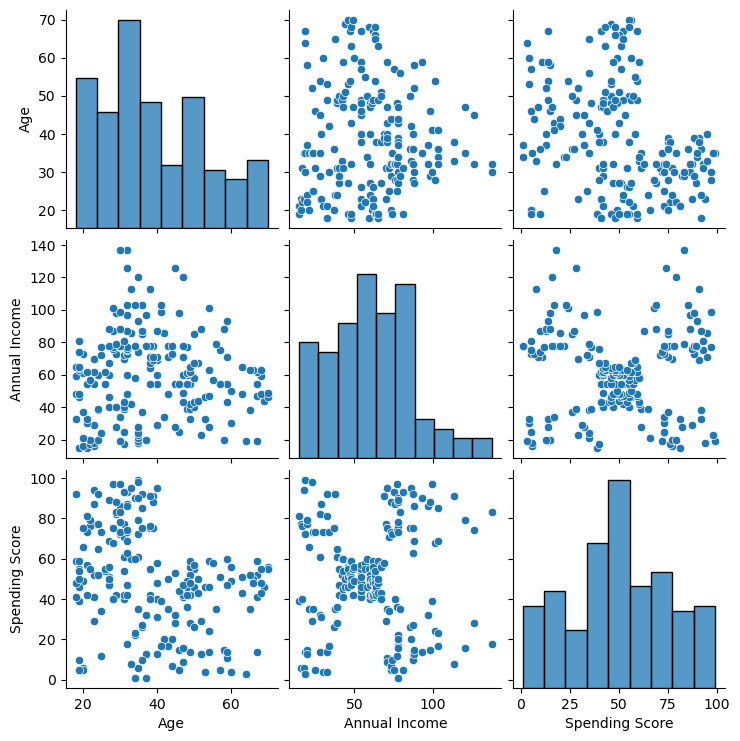

In [21]:
sns.pairplot(df)
plt.show()

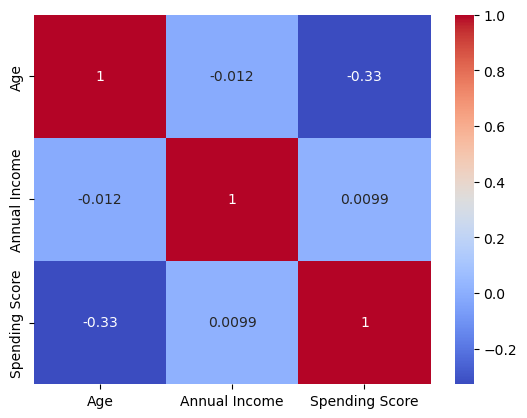

In [20]:
#display correlation matrix
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

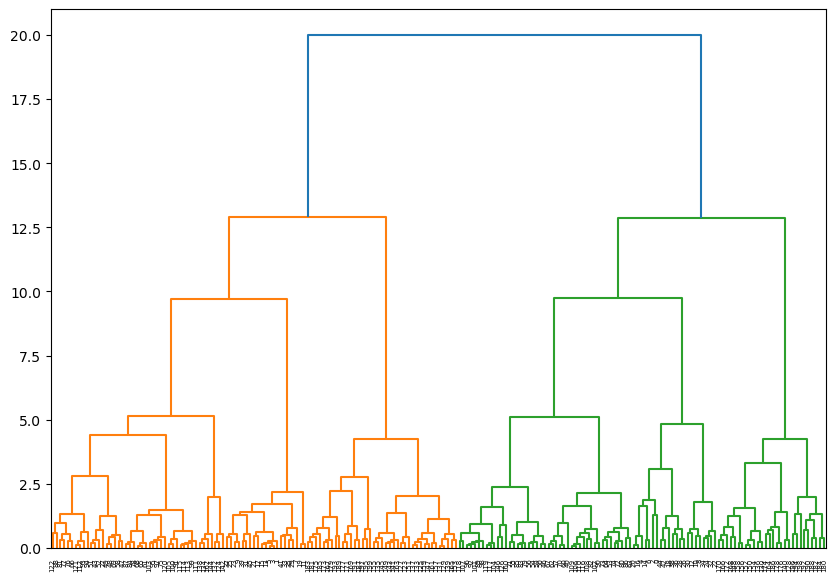

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(scaled_data, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.show()

In [27]:
model=AgglomerativeClustering(n_clusters=5)
model.fit(scaled_data)
labels=model.labels_
labels

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 1, 0, 4, 0,
       4, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 1, 2, 3, 2, 3, 2,
       0, 2, 0, 2, 3, 2, 0, 2, 3, 2, 0, 2, 0, 2, 1, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 1, 2, 0, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2])

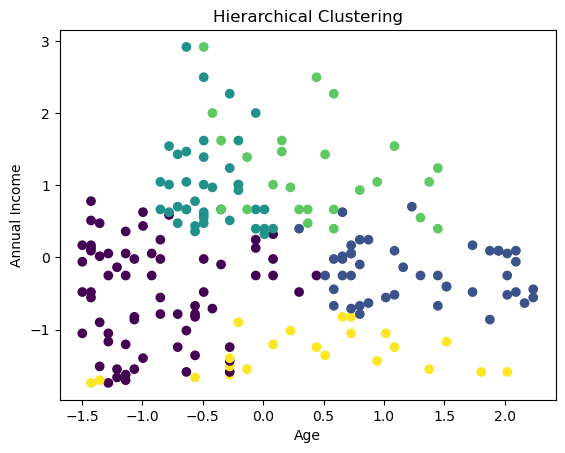

In [29]:
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=labels, cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()

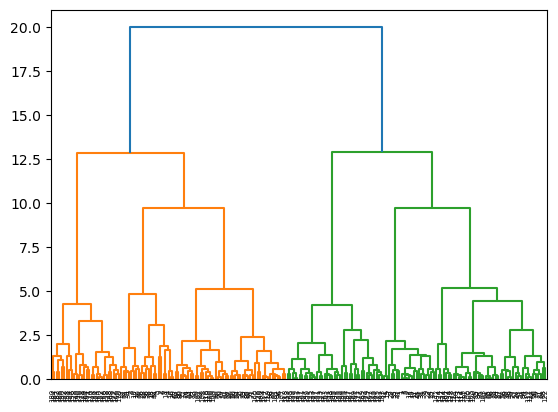

In [30]:
plt.Figure(figsize=(10, 7))
dendrogram(linked)
plt.show()

In [32]:
from scipy.cluster.hierarchy import fcluster
clusters=fcluster(linked, t=150, criterion='distance')
n_clusters=len(set(clusters))
print(f'Number of clusters: {n_clusters}')

Number of clusters: 1


In [45]:
df['labels'] = labels
df.head()

,Age,Annual Income,Spending Score,labels
0,19,15,39,4
1,21,15,81,0
2,20,16,6,4
3,23,16,77,0
4,31,17,40,4


In [46]:
x=df.drop(columns=['labels'])
y=df['labels']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
model.fit(x_train, y_train)
y_pred = model.fit_predict(x_test)

In [53]:
scheme = silhouette_score(x_test, y_pred)
print(f'Silhouette Score: {scheme}')

Silhouette Score: 0.4489597158376336


In [54]:
import joblib
joblib.dump(model, 'hierarchical_model.pkl')

['hierarchical_model.pkl']

In [55]:
df.to_csv('clustered_mall_customers.csv', index=False)

In [56]:
import pandas as pd
import joblib
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("Mall_Customers.csv")
df.drop(columns=["CustomerID", "Gender"], inplace=True)

# ==============================
# FEATURES FOR CLUSTERING
# ==============================
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# ==============================
# KMEANS CLUSTERING (K = 6)
# ==============================
kmeans = KMeans(n_clusters=6, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# ==============================
# SAVE CLUSTERED CSV
# ==============================
df.to_csv("clustered_mall_customers.csv", index=False)

# ==============================
# SCALING (IMPORTANT)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# TRAIN CLASSIFIER
# ==============================
y = df['Cluster']
model = DecisionTreeClassifier(random_state=42)
model.fit(X_scaled, y)

# ==============================
# SAVE MODEL & SCALER
# ==============================
joblib.dump(model, "customer_segmentation_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

c:\Users\yashw\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Model and scaler saved successfully!
